# `remove_overlaps`



In [10]:
import porespy as ps
import matplotlib.pyplot as plt
import numpy as np
ps.visualization.set_mpl_style()

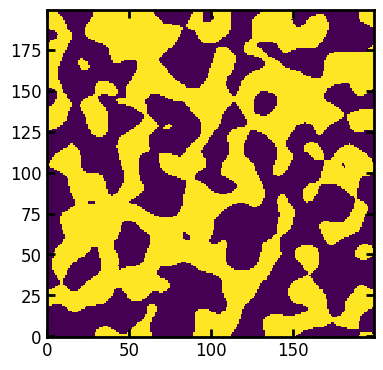

In [11]:
im = ps.generators.blobs([200, 200])
fig, ax = plt.subplots(figsize=[4, 4])
ax.imshow(im);

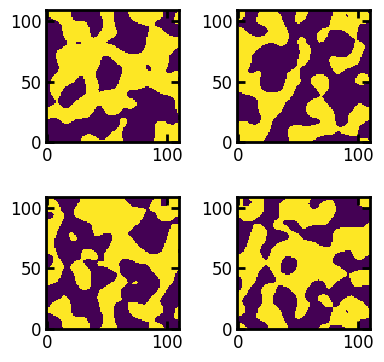

In [12]:
slices = ps.tools.get_slices_grid(im=im, divs=2, overlap=10)
fig, ax = plt.subplots(2, 2, figsize=[4, 4])
for i, s in enumerate(slices):
    ax[i // 2][i % 2].imshow(im[s])

Now let's colorize each image differently, then we can see how to rejoin them:

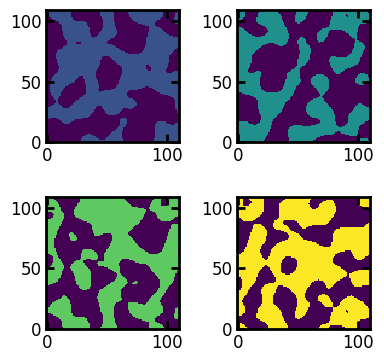

In [13]:
new_ims = []
for i, s in enumerate(slices):
    new_ims.append(im[s]/1.0*(i + 1))

fig, ax = plt.subplots(2, 2, figsize=[4, 4])
for i, s in enumerate(slices):
    ax[i // 2][i % 2].imshow(new_ims[i], vmax=4)

In [14]:
new_slices_global, new_slices_sub = ps.tools.remove_overlaps(slices, overlap=10, shape=im.shape)

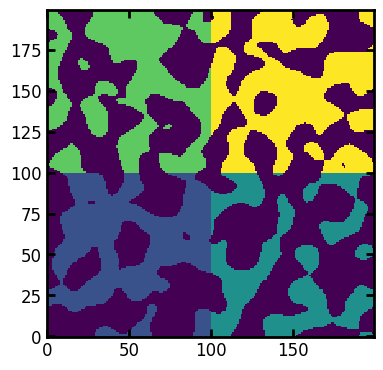

In [15]:
im_new = np.zeros_like(im, dtype=float)
for i, s in enumerate(new_slices_global):
    im_new[s] = new_ims[i][new_slices_sub[i]]

fig, ax = plt.subplots(figsize=[4, 4])
ax.imshow(im_new);